# Run this to enable loading from relative packes

In [1]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
  import importlib, sys, pathlib # https://stackoverflow.com/a/50395128/11996983
  PKG = %pwd
  PKG = pathlib.Path(PKG)
  root_parent_level = 1
  root = PKG
  full_pkg = f"{root.name}"
  for _ in range(root_parent_level):
    root = root.parent
    full_pkg = f"{root.name}.{full_pkg}"
    MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
    MODULE_NAME = f"{root.name}"
    spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
    module = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = module
    spec.loader.exec_module(module)
  __package__ = full_pkg


# Save plots with no embeded fonts

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']


# Figures Save Path

In [3]:
fig_save_prefix = f"../results/2P/"

# Common Imports

In [4]:
from .common.cache import loadCachedOrRunNSave as ld
from .common.definitions import BrainRegion
import numpy as np
from tqdm.auto import tqdm
ACQ_RATE = 30 # TODO: Read dynamically

In [ ]:
from .behavior.util.splitdata import splitStimulusTimeByQuantile
import pandas as pd

def assignOriginalQuantile(df):
    df_li = []
    assert df.index.nunique() == len(df)
    len_before = len(df)
    df = df[df.calcStimulusTime.notnull()]
    # print(f"Dropping {len_before - len(df)} rows with null calcStimulusTime")
    org_df = df.copy()
    # Each trial has multiple epochs, drop them and keep only one row per trial
    df = df.drop_duplicates(subset=["Name", "Date", "SessionNum", "TrialNumber"])
    df = df.reset_index(drop=True)
    for quantile_idx, quantile_df in splitStimulusTimeByQuantile(df):
        quantile_df = quantile_df.copy()
        quantile_df["quantile_idx"] = quantile_idx
        df_li.append(quantile_df)
    df = pd.concat(df_li)
    # Assign back to original df
    org_df_li = []
    org_df["quantile_idx"] = -1
    for idx, row in df.iterrows():
        mask = (
            (org_df["Name"] == row["Name"]) &
            (org_df["Date"] == row["Date"]) &
            (org_df["SessionNum"] == row["SessionNum"]) &
            (org_df["TrialNumber"] == row["TrialNumber"])
        )
        temp_df = org_df[mask].copy()
        temp_df["quantile_idx"] = row["quantile_idx"]
        org_df_li.append(temp_df)
    reassigned_df = pd.concat(org_df_li)
    # reassigned_df = reassigned_df.sort_index()
    reassigned_df = reassigned_df.sort_values(["Name", "Date", "SessionNum", "TrialNumber",
                                               "trace_start_idx", "state_id" ])
    reassigned_df = reassigned_df.reset_index(drop=True)
    return reassigned_df

# Load source data

In [6]:
_FP = "../data/2p/df_all_by_epoch_df_f_filtered.pkl"
import pickle
with open(_FP, "rb") as f:
  df_all_by_epoch = pickle.load(f)

In [ ]:
from .pipeline import tracesnormalize
from .twop.alignsampling import alignSampling
import pandas as pd

normalization = tracesnormalize.NoNormalization()


TIME_BEFORE_SAMPLING = 0.1
TIME_AFTER_MOVEMENT = 0.1
NUM_QUANTILES = 3

_alignSamplingKargs = dict(normalization=normalization,
                           time_before_sampling=TIME_BEFORE_SAMPLING,
                           time_after_sampling=TIME_AFTER_MOVEMENT,)

In [8]:
%%capture
normed_sampling_df = alignSampling(df_all_by_epoch.copy(), normalize_epoch_time=True,
                                   **{k:v for k,v in _alignSamplingKargs.items() if k != 'normalization'},
                                   normalization=tracesnormalize.NormalizeZScore(set_name="neuronal"),
                                   normalize_sessions_before_splitting=True
                                   )
normed_sampling_df["epoch"] = "Sampling"

In [9]:
df_all_by_trial_normalized = pd.read_pickle("../data/2p/df_all_by_trial_normalized.pkl")

# Common function to plot

In [10]:
common_kargs = dict(cached_df_avgs={},
                    cache_extra_prefix=f"normalized_sampling_{NUM_QUANTILES}_quantiles_align_{TIME_BEFORE_SAMPLING}s_before_sampling_{TIME_AFTER_MOVEMENT}s_after_movement")

In [ ]:
from .twop.plottracesavg import plotNormalized as plotNormalizedT, Combinations, Plots
from .twop.evd_conditions_common import SplitLevelBy
from functools import partial

def avg(df, cached_df_avgs, cache_extra_prefix, split_by_quantile,
        split_by_session,  combination : Combinations,
        # only_sgf : bool,
        resort_heatmaps : bool, resort_using_all : bool,
        only_common_sort_not_common_rng : bool,
        save_figs, plot_only_ids_li : list = [],
        plot_only_ids_exact_match : bool = False,
        restrict_heatmap_sorting_to_epochs : list = [],
        sgf_data_col : str = None, sgf_prior_data_col : str = None,
        plot_traces : bool = False, only_sgf : bool = None,
        skip_group_infos : dict = {},
        ):
    '''
    only_common_sort_not_common_rng : bool
        If False, the 0-1 of each row will be calculated across all generated
        heatmaps, not just relative to the current average row. I.e, when True,
        you are guaranteed that each row will go from 0 to 1.
    '''
    if resort_using_all:
        assert resort_heatmaps, (
            "Doesn't make sense to resort all without `resort_heatmaps = True`")

    if not len(plot_only_ids_li):
        assert split_by_session, ("Set `split_by_session = True`, otherwise "
        "session will be saved under another folder with wrong session name")

    if only_sgf:
        assert sgf_data_col is not None, (
                           "If only_sgf is True, sgf_data_col must be provided")
    if sgf_data_col is not None:
        if only_sgf is None:
            only_sgf = True
        with open("../data/2p/sgf_all.pkl", "rb") as f:
            sgf_traces_df = pickle.load(f)
            sgf_traces_df = sgf_traces_df[sgf_traces_df.data_col == sgf_data_col]
            if sgf_prior_data_col is not None:
                sgf_traces_df = sgf_traces_df[sgf_traces_df.prior_data_col == sgf_prior_data_col]
            else:
                sgf_traces_df = sgf_traces_df[sgf_traces_df.prior_data_col.isnull()]
            sgf_traces_set = set(sgf_traces_df.long_trace_id)
            sgf_traces_set = {f"{_id.rsplit('_', 1)[1]}_{_id.rsplit('_', 1)[0]}"
                              for _id in sgf_traces_set}
        # print("sgf_traces_set:", sgf_traces_set)

    combinations = [combination]
    plots = [Plots.Heatmap] if not plot_traces else [Plots.Traces]
    def onlyTracesIds(set_name, traces_ids, group_info):
        # print("group info:", group_info)
        good_set = set()
        printed_once = False
        #q_idx = group_info["quantile_idx"]
        # q_sgf_set = sgf_set_by_idx_dict[q_idx]
        for key, val in skip_group_infos.items():
            if group_info.get(key, None) == val:
                return good_set
        if set_name == "neuronal":
            for trace_id in traces_ids:
                if not printed_once:
                    # print("trace_id:", trace_id, " - group_info:", group_info)
                    printed_once = True
                if not len(plot_only_ids_li) or (
                  any(((key in trace_id) if not plot_only_ids_exact_match else (key == trace_id)
                       for key in plot_only_ids_li))):

                    if not only_sgf or trace_id in sgf_traces_set:
                        # print("Found match:", trace_id)
                        good_set.add(trace_id)
                    # else:
                    #    print("Not accepted...")
                    # good_set.add(trace_id)
        # print("good_set:", len(good_set), "- out of:", len(sgf_traces_set))
        return good_set

    def heatMapSortSrcDf(df, split_level, by_kws, match_cols):
        # print("By split level:", split_level)
        # print("Local Match cols:", match_cols)
        # print("By kws:", by_kws)
        #   display(pd.DataFrame(df))
        #   display(df[0])
        if split_by_quantile:
            df = df[df.quantile_idx == 3]
        if "DVstr" in by_kws:
            df = df[df.DVstr == "Easy"]
        if "ChoiceCorrect" in by_kws:
            df = df[df.ChoiceCorrect == True]
        if "ChoiceLeft" in by_kws:
            df = df[df.ChoiceLeft == True]
        if "PrevChoiceLeft" in by_kws:
            df = df[df.PrevChoiceLeft == True]
        if "PrevChoiceCorrect" in by_kws:
            df = df[df.PrevChoiceCorrect == False]
        match_cols = [col for col in match_cols if col != "quantile_idx"]
        # display(df)
        is_df_one_of_them = True
        return df, match_cols, split_level, is_df_one_of_them

    heatmap_sort_str = "" # Will be re-assigned below
    def renameSave(args):
        # display(args)
        dscrp = "" #combination.name
        # If it's combined, write it as the first thing
        is_comb_all_sess = not len(plot_only_ids_li) and not split_by_session
        if is_comb_all_sess:
            dscrp += "_all_sess"
        if split_by_quantile:
            dscrp += f"_q{args['quantile_idx']}"
        combination_kargs = combination.avg_kargs.copy()
        if combination_kargs.pop("by_difficulty", False):
            dscrp += f"_Diff{args['DVstr']}"
        if combination_kargs.pop("by_correctness", False):
            dscrp += "_Correct" if args["ChoiceCorrect"] else "_Incorrect"
        if combination_kargs.pop("by_direction", False):
            dscrp += "_Left" if args["ChoiceLeft"] else "_Right"
        if combination_kargs.pop("by_prev_direction", False):
            dscrp += "_PrevLeft" if args["PrevChoiceLeft"] else "_PrevRight"
        if combination_kargs.pop("by_prev_correct", False):
            dscrp += "_PrevIncorrect" if args["PrevChoiceCorrect"] else "_PrevCorrect"
        assert not len(combination_kargs), f"Unhandled kargs: {combination_kargs}"
        # if "Layer" in args:
        #     dscrp += f"_Layer_{args['Layer']}"
        # if only_sgf:
        if only_sgf and not plot_traces:
            dscrp += f"_only_sgf_{sgf_data_col}"
            if sgf_prior_data_col is not None:
                dscrp += f"_prior_{sgf_prior_data_col}"
        if not is_comb_all_sess:
            dscrp += f"_{args['ShortName']}"
        if "BrainRegion" in args and ~np.isnan(args['BrainRegion']):
            br_str = str(BrainRegion(args['BrainRegion']))
            br_str = br_str.split("_")[0]
            dscrp += f"_{br_str}"
        if not plot_traces:
            dscrp += f"_{heatmap_sort_str}"
            dscrp = dscrp[1:] # Remove first _
        return dscrp

    cur_split_level = SplitLevelBy.BrainRegion
    if split_by_quantile:
        cur_split_level |= SplitLevelBy.Quantile
    if split_by_session:
        cur_split_level |= SplitLevelBy.Session

    plotNormalized = partial(plotNormalizedT, save_figs_outliers=False,
                            fig_save_prefix=fig_save_prefix,
                            normalization=normalization,
                            split_level=cur_split_level,
                            align_feedback_time=None,
                            limit_end_epoch=True,
                            #normalize_by_session=normalize_by_session,
                            filter_outlier_trials=False)

    if resort_heatmaps:
        if resort_using_all:
            heatMapSortSrcDf = "None"
            heatmap_sort_str = "sorted_to_all"
        else:
            heatMapSortSrcDf = heatMapSortSrcDf
            heatmap_sort_str = "sorted_to"
            combination_kargs = combination.avg_kargs.copy()
            if split_by_quantile:
                heatmap_sort_str += "_q3"
            if combination_kargs.pop("by_difficulty", False):
                heatmap_sort_str += "_Easy"
            if combination_kargs.pop("by_correctness", False):
                heatmap_sort_str += "_Correct"
            if combination_kargs.pop("by_direction", False):
                heatmap_sort_str += "_Left"
            if combination_kargs.pop("by_prev_direction", False):
                heatmap_sort_str += "_PrevLeft"
            if combination_kargs.pop("by_prev_correct", False):
                heatmap_sort_str += "_PrevIncorrect"
            assert not len(combination_kargs), f"Unhandled kargs: {combination_kargs}"

        heatmap_sort_str += "_self_rng" if only_common_sort_not_common_rng else "_shared_rng"
    else:
        heatMapSortSrcDf = None
        heatmap_sort_str = "sorted_to_itself"

    plot_save_dir_prefix = ""
    plot_save_dir_prefix += "sgf/" if only_sgf else "sgf_and_not_sgf/"
    plot_save_dir_prefix += "quantiles/" if split_by_quantile else "no_quantiles/"
    plotNormalized(df_concat_norm=df, df_concat_without_feedback=None,
                    combinations=combinations, cached_df_avgs=cached_df_avgs,
                    plots=plots,
                    save_figs=save_figs,
                    plots_kargs={Plots.Heatmap:dict(plot_y_ids=True,
                                                    dpi=300,
                                                    heatMapSortSrcDf=heatMapSortSrcDf,
                                                    renameSaveFn=renameSave,
                                                    save_ext="svg",
                                                    only_common_sort_not_common_rng=only_common_sort_not_common_rng,
                                                    restrict_sorting_to_epochs=restrict_heatmap_sorting_to_epochs,
                                                    ),
                                  Plots.Traces:dict(sem_traces=True,
                                                    appendSaveFn=renameSave,
                                                    save_dir_prefix=plot_save_dir_prefix,
                                                    save_ext="svg",)
                                },
                    only_traces_ids=[], #["GP4_23_s8_L50_D250_ALM126"],
                    onlyTraceIdsPlotProcessFn=onlyTracesIds,
                    cache_extra_prefix=cache_extra_prefix,
                    save_context=(["quantile_idx"] if split_by_quantile else []) + \
                                 (["Layer", "BrainRegion", "ChoiceLeft"] if not plot_traces else [])
    )

# Heatmap common combinations

In [117]:
# Heatmaps sorting options
class HeatmapSortingOptions:
    ''' e.g. if plotting a quantile, it will be sorted according to
    in the max. firing position within the quantile sequence itself'''
    SORT_TO_SELF = (False, False)
    '''Resort to another reference heatmap. This will use the second quantile.
    This option is hard-coded for certain cases'''
    RESORT_TO_ANOTHER = (True, False)
    '''Resort to all heatmaps, i.e. use the sequence found in the all trials heatmap'''
    RESORT_TO_ALL = (True, True)

class HeatmapFirinhRangeOptions:
    ''' Each row will be normalized 0-1 within itself'''
    SELF_RNG = True
    ''' Each row will be normalized 0-1 using data from all heatmaps under the same condition'''
    SHARED_RNG = False

def loopHeatmapCombinations(df, split_by_quantile, save_figs, plot_only_sess_li=[],
                            sgf_data_cols_comb_li=[(None, None)],
                            combin_all_sess_li=[False],
                            heatmap_sorting_options_li=[HeatmapSortingOptions.RESORT_TO_ALL],
                            combinations_li=[Combinations.All],
                            heatmap_firing_range_options_li=[HeatmapFirinhRangeOptions.SELF_RNG, HeatmapFirinhRangeOptions.SHARED_RNG],
                            skip_group_infos={}
                            ):
    for _sgf_data_col, _sgf_prior_data_col in sgf_data_cols_comb_li:
        for _combin_all_sess in combin_all_sess_li:
            if _combin_all_sess and len(plot_only_sess_li):
                continue
            for _resort_to_another, _another_is_all in heatmap_sorting_options_li:
                for not_shared_rng in heatmap_firing_range_options_li:
                    for _combination in combinations_li:
                        # Processing: combination.name = 'All' - combin_all_sess = True - resort_to_another = True -
                        # another_is_all = True - only_common_sort_not_common_rng = False - only_sgf = False - split_by_quantile = True
                        print(f"*****Processing: {_combination.name = } - {_combin_all_sess = } - {_resort_to_another = } - {_another_is_all = } - "
                              f"{not_shared_rng = } - {_sgf_data_col = } - {_sgf_prior_data_col = } {split_by_quantile = }")
                        avg(df=df, split_by_quantile=split_by_quantile, **common_kargs, combination=_combination,
                            resort_heatmaps=_resort_to_another, resort_using_all=_another_is_all,
                            only_common_sort_not_common_rng=not_shared_rng,
                            **(dict(split_by_session=False, plot_only_sess_li=[]) if _combin_all_sess else dict(split_by_session=True,
                                                                                                                plot_only_sess_li=plot_only_sess_li)),
                            sgf_data_col=_sgf_data_col, sgf_prior_data_col=_sgf_prior_data_col,save_figs=save_figs,
                            skip_group_infos=skip_group_infos
                            )

In [142]:
%%capture
success = False
# Create first a common All-quantiles heatmap (without breaking to quantiles)
# To use it as sorting reference.
# For make this run so that the cache is created, the figures gets plotted to
# void for now.
loopCombinations(normed_sampling_df, split_by_quantile=False, save_figs=False)
# This won't execute if the above line created
success = True

In [143]:
assert success, "Failed to create the cache properly"

In [ ]:
# Assign quantiles
normed_sampling_quantiles_df = assignOriginalQuantile(normed_sampling_df)

  0%|          | 0/23 [00:00<?, ?it/s]

In [39]:
%%capture
success_quantiles = False
# Also cache the aceraged quantile traces
loopCombinations(normed_sampling_quantiles_df, split_by_quantile=True, save_figs=False)
# This won't execute if the above line created
success_quantiles = True

In [40]:
assert success_quantiles, "Failed to create the quantile cache properly"

## Fig. 3h

*****Processing: _combination.name = 'All' - _combin_all_sess = False - _resort_to_another = True - _another_is_all = True - not_shared_rng = False - _sgf_data_col = None - _sgf_prior_data_col = None split_by_quantile = True
Processing All
Found in cache: normalized_sampling_3_quantiles_align_0.1s_before_sampling_0.1s_after_movement../results/2P/_All_split261
Found in cache: normalized_sampling_3_quantiles_align_0.1s_before_sampling_0.1s_after_movement../results/2P/_All_split5
Splitting....
gen_by_processors: ['epoch']
Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer', 'quantile_idx']
Processing: Split data by trial ['epoch']


  0%|          | 0/3 [00:00<?, ?it/s]

Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer']
Processing: Ordering activity by peak activity ascendingly


  0%|          | 0/23 [00:00<?, ?it/s]

Processing: Collapsing the dataframes back into one dataframe
Only ids: ['19_GP4_28_S2_L51_D250_M2L', '11_GP4_28_S2_L51_D250_M2L', '43_GP4_28_S2_L51_D250_M2L', '220_GP4_28_S2_L51_D250_M2L', '1_GP4_28_S2_L51_D250_M2L', '216_GP4_28_S2_L51_D250_M2L', '90_GP4_28_S2_L51_D250_M2L', '13_GP4_28_S2_L51_D250_M2L', '117_GP4_28_S2_L51_D250_M2L', '38_GP4_28_S2_L51_D250_M2L', '27_GP4_28_S2_L51_D250_M2L', '95_GP4_28_S2_L51_D250_M2L', '23_GP4_28_S2_L51_D250_M2L', '5_GP4_28_S2_L51_D250_M2L', '123_GP4_28_S2_L51_D250_M2L', '10_GP4_28_S2_L51_D250_M2L', '20_GP4_28_S2_L51_D250_M2L', '431_GP4_28_S2_L51_D250_M2L', '59_GP4_28_S2_L51_D250_M2L', '52_GP4_28_S2_L51_D250_M2L', '97_GP4_28_S2_L51_D250_M2L', '39_GP4_28_S2_L51_D250_M2L', '3_GP4_28_S2_L51_D250_M2L', '36_GP4_28_S2_L51_D250_M2L', '60_GP4_28_S2_L51_D250_M2L', '80_GP4_28_S2_L51_D250_M2L', '31_GP4_28_S2_L51_D250_M2L', '22_GP4_28_S2_L51_D250_M2L', '141_GP4_28_S2_L51_D250_M2L', '206_GP4_28_S2_L51_D250_M2L', '18_GP4_28_S2_L51_D250_M2L', '87_GP4_28_S2_L51_D250_M

  0%|          | 0/1 [00:00<?, ?it/s]

Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer', 'quantile_idx']
Processing: Split data by trial ['epoch']


  0%|          | 0/3 [00:00<?, ?it/s]

Processing: Plotting traces data as heatmap


  0%|          | 0/3 [00:00<?, ?it/s]

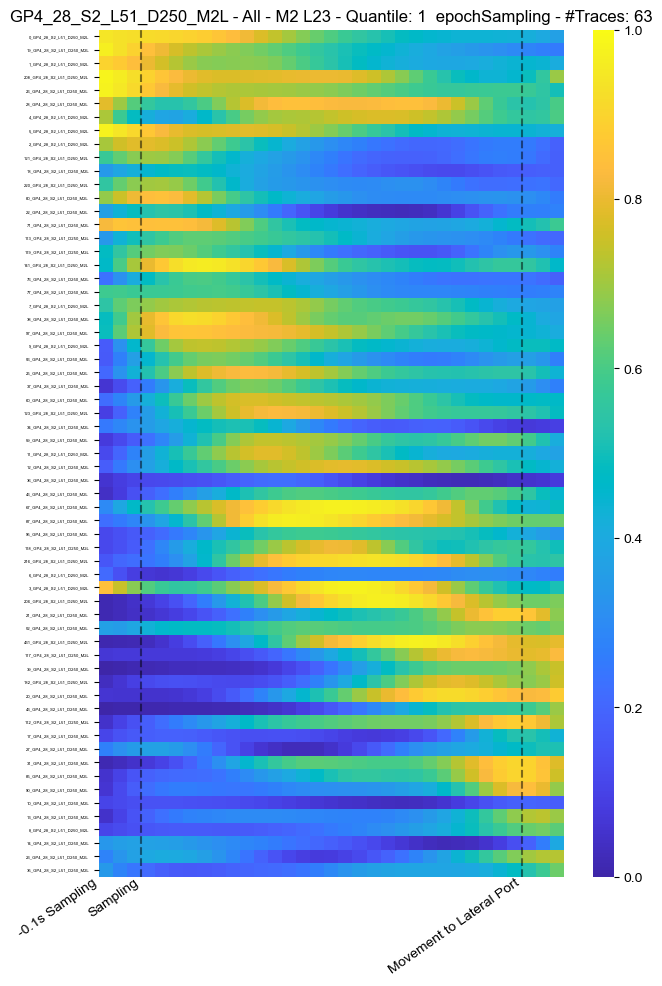

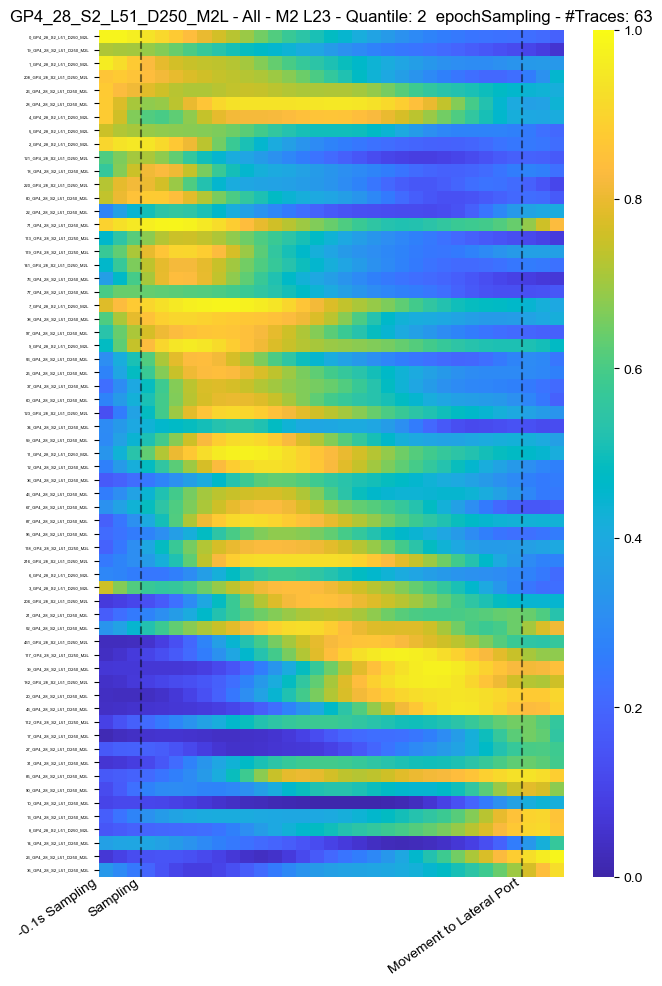

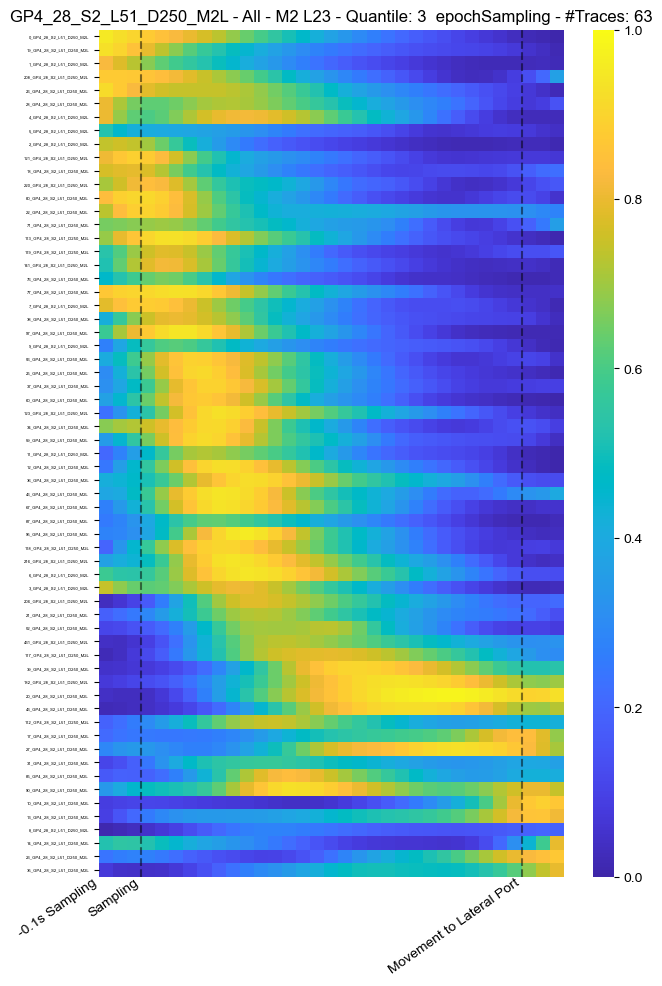

In [170]:
# This differs a little from the currently submitted version of the paper, as we didn't
# implement originally subset sorting for neurons that has the same peak activity idx. Currently,
# it's being sorted by idx then key (keys are strings here, so lexicographically).
loopHeatmapCombinations(normed_sampling_quantiles_df, split_by_quantile=True, save_figs=False,
                        plot_only_sess_li=["GP4_28_S2_L51_D250_M2L"],
                        heatmap_sorting_options_li=[HeatmapSortingOptions.RESORT_TO_ALL],
                        heatmap_firing_range_options_li=[HeatmapFirinhRangeOptions.SHARED_RNG],
                        # skip_group_infos={"quantile_idx":2}
                        )

### All sessions

In [172]:
loopHeatmapCombinations(normed_sampling_quantiles_df, split_by_quantile=True, save_figs=True,
                        heatmap_sorting_options_li=[HeatmapSortingOptions.RESORT_TO_ALL],
                        heatmap_firing_range_options_li=[HeatmapFirinhRangeOptions.SHARED_RNG],
                        # skip_group_infos={"quantile_idx":2}
                        )

*****Processing: _combination.name = 'All' - _combin_all_sess = False - _resort_to_another = True - _another_is_all = True - not_shared_rng = False - _sgf_data_col = None - _sgf_prior_data_col = None split_by_quantile = True
Processing All
Found in cache: normalized_sampling_3_quantiles_align_0.1s_before_sampling_0.1s_after_movement../results/2P/_All_split261
Found in cache: normalized_sampling_3_quantiles_align_0.1s_before_sampling_0.1s_after_movement../results/2P/_All_split5
Splitting....
gen_by_processors: ['epoch']
Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer', 'quantile_idx']
Processing: Split data by trial ['epoch']


  0%|          | 0/69 [00:00<?, ?it/s]

Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer']
Processing: Ordering activity by peak activity ascendingly


  0%|          | 0/23 [00:00<?, ?it/s]

Processing: Collapsing the dataframes back into one dataframe
Only ids: ['75_GP4_85_s9_L70_D250_ALM', '66_gp4_81_S8_L65_D250_ALM', '43_GP4_28_S2_L51_D250_M2L', '4_GP4_85_s7_L70_D250_ALM', '30_GP4_80_S4_L50_D250_M2m', '67_GP4_23_s7_L50_D250_ALM', '16_GP4_85_s2_L100_D250_mm2', '96_GP4_85_s7_L70_D250_ALM', '448_GP4_23_s3_L50_D250_M2', '40_GP4_23_s8_L50_D250_ALM', '13_GP4_85_s8_L60_D250_ALM', '287_GP4_23_s7_L50_D250_ALM', '245_GP4_23_s8_L50_D250_ALM', '97_GP4_23_s6_L50_D250_ALM', '62_GP4_28_S1_L41_D250_M2L', '318_GP4_23_S1_L50_D250_mm2', '374_GP4_23_s6_L50_D250_ALM', '18_GP4_85_s3_L70_D250_mm2', '51_GP4_85_s8_L60_D250_ALM', '115_GP4_85_s3_L70_D250_mm2', '22_gp4_81_S8_L65_D250_ALM', '176_GP4_23_s7_L50_D250_ALM', '1_GP4_85_s8_L60_D250_ALM', '62_gp4_81_S8_L65_D250_ALM', '16_GP4_85_s10_L70_D250_ALM', '80_GP4_28_S2_L51_D250_M2L', '24_GP4_85_s10_L70_D250_ALM', '95_GP4_85_s3_L70_D250_mm2', '35_GP4_85_s8_L60_D250_ALM', '0_GP4_23_s3_L50_D250_M2', '36_GP4_85_s2_L100_D250_mm2', '141_GP4_28_S2_L51_D25

  0%|          | 0/23 [00:00<?, ?it/s]

Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer', 'quantile_idx']
Processing: Split data by trial ['epoch']


  0%|          | 0/69 [00:00<?, ?it/s]

Processing: Plotting traces data as heatmap


  0%|          | 0/69 [00:00<?, ?it/s]

## Fig. 4b

*****Processing: _combination.name = 'All' - _combin_all_sess = False - _resort_to_another = False - _another_is_all = False - not_shared_rng = True - _sgf_data_col = None - _sgf_prior_data_col = None split_by_quantile = False
Processing All
Found in cache: normalized_sampling_3_quantiles_align_0.1s_before_sampling_0.1s_after_movement../results/2P/_All_split5
Splitting....
gen_by_processors: ['epoch']
Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer']
Processing: Split data by trial ['epoch']
Processing: Normalized trace between its 0% and 100% percentile values
Processing: Ordering activity by peak activity ascendingly
Processing: Plotting traces data as heatmap


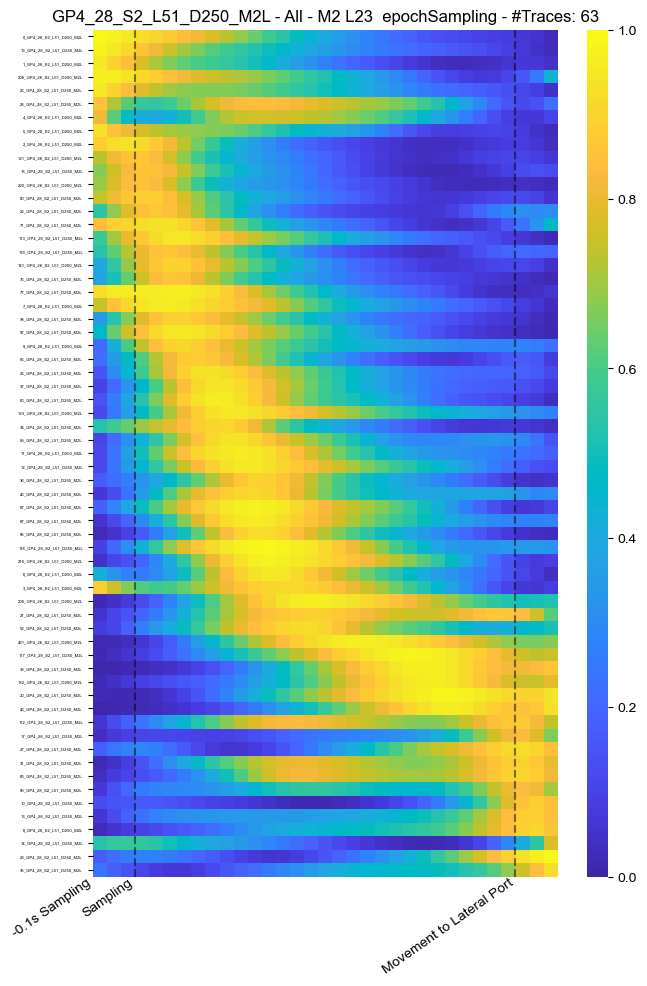

In [183]:
loopHeatmapCombinations(normed_sampling_quantiles_df, split_by_quantile=False, save_figs=False,
                        plot_only_sess_li=["GP4_28_S2_L51_D250_M2L"],
                        heatmap_sorting_options_li=[HeatmapSortingOptions.SORT_TO_SELF],
                        heatmap_firing_range_options_li=[HeatmapFirinhRangeOptions.SELF_RNG],
                        )

### All sessions

In [182]:
loopHeatmapCombinations(normed_sampling_quantiles_df, split_by_quantile=False, save_figs=True,
                        heatmap_sorting_options_li=[HeatmapSortingOptions.SORT_TO_SELF],
                        heatmap_firing_range_options_li=[HeatmapFirinhRangeOptions.SELF_RNG],
                        )

*****Processing: _combination.name = 'All' - _combin_all_sess = False - _resort_to_another = False - _another_is_all = False - not_shared_rng = True - _sgf_data_col = None - _sgf_prior_data_col = None split_by_quantile = False
Processing All
Found in cache: normalized_sampling_3_quantiles_align_0.1s_before_sampling_0.1s_after_movement../results/2P/_All_split5
Splitting....
gen_by_processors: ['epoch']
Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer']
Processing: Split data by trial ['epoch']


  0%|          | 0/23 [00:00<?, ?it/s]

Processing: Normalized trace between its 0% and 100% percentile values


  0%|          | 0/23 [00:00<?, ?it/s]

Processing: Ordering activity by peak activity ascendingly


  0%|          | 0/23 [00:00<?, ?it/s]

Processing: Plotting traces data as heatmap


  0%|          | 0/23 [00:00<?, ?it/s]

# Plot average traces for different combinations

In [26]:
def loopCombinationsTraces(df, split_by_quantile, only_sgf, save_figs):
    local_kargs = common_kargs.copy()
    local_kargs.update(dict(resort_heatmaps=False, resort_using_all=False,
                            only_common_sort_not_common_rng=False, plot_traces=True,
                            split_by_session=True, only_single_sess=False
                            ))
    for combination, sgf_data_col, sgf_prior_data_col in [#(Combinations.All, None, None),
                                                          (Combinations.Direction, "ChoiceLeft", None),
                                                          #(Combinations.ChoiceCorrect, "ChoiceCorrect", None),
                                                          #(Combinations.Evidence, "IsEasy", None),
                                                          #(Combinations.PrevDirection, "PrevChoiceLeft", None),
                                                          #(Combinations.PrevChoiceCorrect, "PrevChoiceCorrect", None),
                                                        ]:
        # Processing: combination.name = 'All' - combin_all_sess = True - resort_to_another = True -
        # another_is_all = True - only_common_sort_not_common_rng = False - only_sgf = False - split_by_quantile = True
        print(f"*****Processing: {combination.name = } -  - "
              f" {sgf_data_col = } - {sgf_prior_data_col = } {split_by_quantile = }")
        avg(df=df, split_by_quantile=split_by_quantile, **local_kargs, combination=combination,
            sgf_data_col=sgf_data_col, sgf_prior_data_col=sgf_prior_data_col, save_figs=save_figs,
            only_sgf=only_sgf)

In [ ]:
%%capture
success_traces_choices = False
# Build cache for choices averaged
loopCombinationsTraces(normed_sampling_quantiles_df,  only_sgf=True,
                       split_by_quantile=False, save_figs=False)
# This won't execute if the above line created
success_traces_choices = True

In [ ]:
assert success_traces_choices, "Failed to create the traces choices cache properly"

In [ ]:
loopCombinationsTraces(normed_sampling_quantiles_df,  only_sgf=True,
                       split_by_quantile=False, save_figs=False)

# Feedback heatmaps

In [ ]:
align_feedback_time = 0.5 # sec
limit_end_epoch = True
feedback_common_kwargs = dict(cached_df_avgs={},
                              cache_extra_prefix=f"feedback_normalized_align_feedback_{align_feedback_time}s_limit_end_{limit_end_epoch}",
                              df=df_all_by_trial_normalized,
                              split_by_quantile=False,
                              resort_heatmaps=True, resort_using_all=True,
                              only_common_sort_not_common_rng=False,
                              split_by_session=True, )

In [ ]:
%%capture
success_feedback = False
avg(plot_traces=False, combination=Combinations.All,
    **feedback_common_kwargs, save_figs=False)
# This won't execute if the above line created
success_feedback = True

In [193]:
assert success_feedback, "Failed to create the feedback cache properly"

Processing All
Found in cache: feedback_normalized_align_feedback_0.5s_limit_end_True../results/2P/_All_split5
Found in cache: feedback_normalized_align_feedback_0.5s_limit_end_True../results/2P/_All_split5
Splitting....
gen_by_processors: ['epoch']
Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer']
Processing: Split data by trial ['epoch']
Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer']
Processing: Ordering activity by peak activity ascendingly


  0%|          | 0/23 [00:00<?, ?it/s]

Processing: Collapsing the dataframes back into one dataframe
Only ids: ['19_GP4_28_S2_L51_D250_M2L', '195_GP4_28_S2_L51_D250_M2L', '32_GP4_28_S2_L51_D250_M2L', '11_GP4_28_S2_L51_D250_M2L', '43_GP4_28_S2_L51_D250_M2L', '109_GP4_28_S2_L51_D250_M2L', '216_GP4_28_S2_L51_D250_M2L', '1_GP4_28_S2_L51_D250_M2L', '90_GP4_28_S2_L51_D250_M2L', '13_GP4_28_S2_L51_D250_M2L', '117_GP4_28_S2_L51_D250_M2L', '38_GP4_28_S2_L51_D250_M2L', '336_GP4_28_S2_L51_D250_M2L', '27_GP4_28_S2_L51_D250_M2L', '95_GP4_28_S2_L51_D250_M2L', '23_GP4_28_S2_L51_D250_M2L', '48_GP4_28_S2_L51_D250_M2L', '33_GP4_28_S2_L51_D250_M2L', '5_GP4_28_S2_L51_D250_M2L', '348_GP4_28_S2_L51_D250_M2L', '123_GP4_28_S2_L51_D250_M2L', '431_GP4_28_S2_L51_D250_M2L', '20_GP4_28_S2_L51_D250_M2L', '10_GP4_28_S2_L51_D250_M2L', '59_GP4_28_S2_L51_D250_M2L', '264_GP4_28_S2_L51_D250_M2L', '50_GP4_28_S2_L51_D250_M2L', '52_GP4_28_S2_L51_D250_M2L', '122_GP4_28_S2_L51_D250_M2L', '97_GP4_28_S2_L51_D250_M2L', '39_GP4_28_S2_L51_D250_M2L', '3_GP4_28_S2_L51_D25

  0%|          | 0/1 [00:00<?, ?it/s]

Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer']
Processing: Split data by trial ['epoch']
Processing: Plotting traces data as heatmap


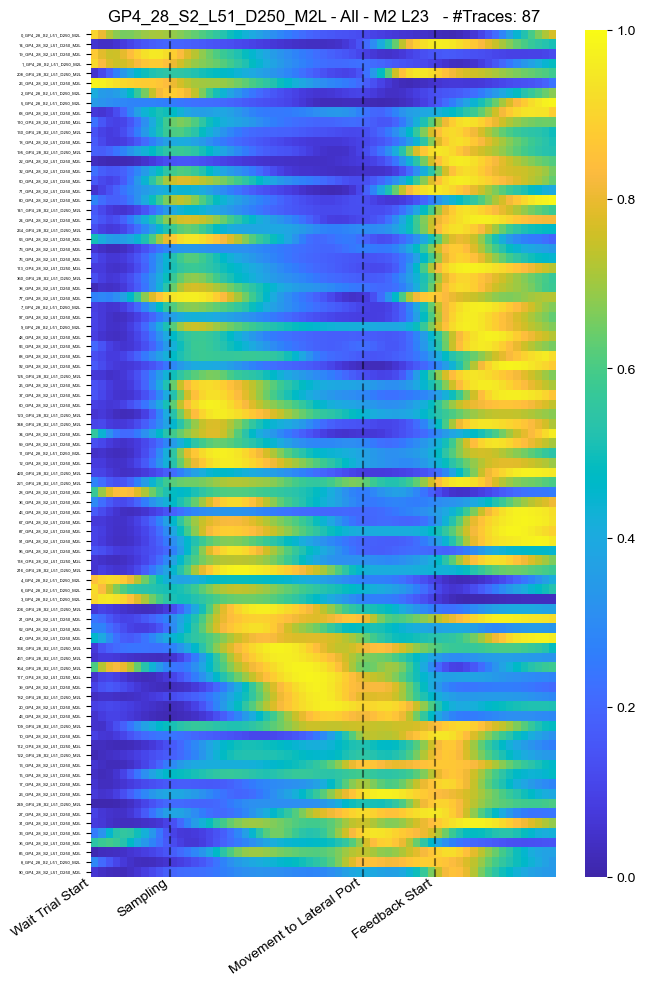

In [ ]:
avg(plot_traces=False, combination=Combinations.All,
    plot_only_ids_li=["GP4_28_S2_L51_D250_M2L"],
    restrict_heatmap_sorting_to_epochs=["Sampling"],
    **feedback_common_kwargs, save_figs=False)

In [ ]:
%%capture
success_feedback2 = False
avg(plot_traces=False, combination=Combinations.PrevChoiceCurDir,
    **feedback_common_kwargs, save_figs=False)
avg(plot_traces=False, combination=Combinations.PrevChoiceCorrect,
    **feedback_common_kwargs, save_figs=False)
avg(plot_traces=False, combination=Combinations.Direction,
    **feedback_common_kwargs, save_figs=False)
# This won't execute if the above line created
success_feedback2 = True

In [196]:
assert success_feedback2, "Failed to create the feedback cache properly"

## Traces

## Fig. 5c bottom

Processing PrevChoiceCurDir
Found in cache: feedback_normalized_align_feedback_0.5s_limit_end_True../results/2P/_PrevChoiceCurDir_split5
only_traces_ids: ['___________________asdasdRandom', '45_GP4_28_S1_L41_D250_M2L']
local_areas_colors: <function DirectionClrFn at 0x000001B2CA3CC5E0>
multiple_trace_ids_per_plot: False
plotter only traces ids: []
Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer']
Processing: Loop through the traces one by one...


Iterating traces:   0%|          | 0/1 [00:00<?, ?it/s]

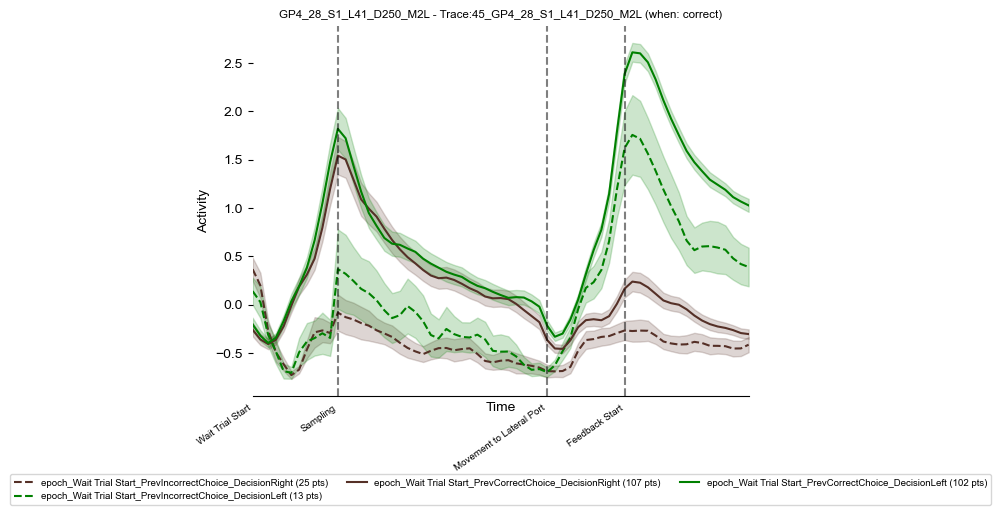

In [256]:
avg(plot_traces=True, combination=Combinations.PrevChoiceCurDir,
    **feedback_common_kwargs,
    #sgf_data_col=False, sgf_prior_data_col=False,
    plot_only_ids_li=["45_GP4_28_S1_L41_D250_M2L"],
    plot_only_ids_exact_match=True,
    save_figs=False)

## Fig. 5c top left

Processing PrevChoiceCorrect
Found in cache: feedback_normalized_align_feedback_0.5s_limit_end_True../results/2P/_PrevChoiceCorrect_split5
only_traces_ids: ['___________________asdasdRandom', '45_GP4_28_S1_L41_D250_M2L']
local_areas_colors: <function ChoiceOutcomeClrFn at 0x000001B2CA3CDEE0>
multiple_trace_ids_per_plot: False
plotter only traces ids: []
Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer']
Processing: Loop through the traces one by one...


Iterating traces:   0%|          | 0/1 [00:00<?, ?it/s]

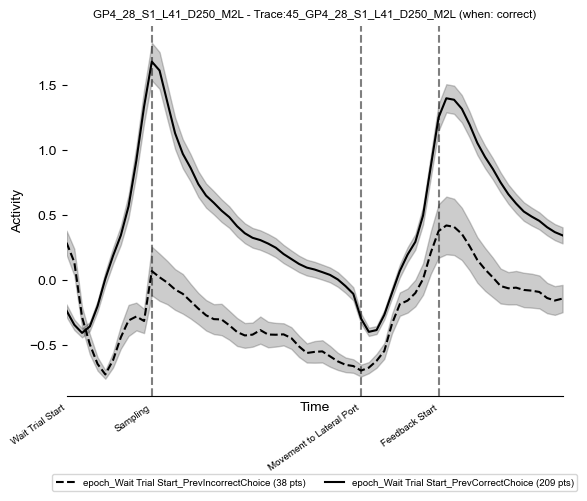

In [259]:
avg(plot_traces=True, combination=Combinations.PrevChoiceCorrect,
    **feedback_common_kwargs,
    #sgf_data_col=False, sgf_prior_data_col=False,
    plot_only_ids_li=["45_GP4_28_S1_L41_D250_M2L"],
    plot_only_ids_exact_match=True,
    save_figs=False)

## Fig. 5c top right

Processing Direction
Found in cache: feedback_normalized_align_feedback_0.5s_limit_end_True../results/2P/_Direction_split5
only_traces_ids: ['___________________asdasdRandom', '45_GP4_28_S1_L41_D250_M2L']
local_areas_colors: <function DirectionClrFn at 0x000001B2CA3CC5E0>
multiple_trace_ids_per_plot: False
plotter only traces ids: []
Processing: Split data by trial ['Name', 'Date', 'SessionNum', 'BrainRegion', 'Layer']
Processing: Loop through the traces one by one...


Iterating traces:   0%|          | 0/1 [00:00<?, ?it/s]

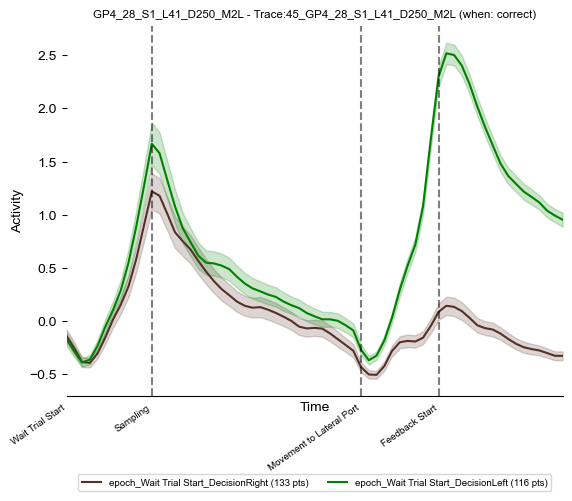

In [261]:
avg(plot_traces=True, combination=Combinations.Direction,
    **feedback_common_kwargs,
    #sgf_data_col=False, sgf_prior_data_col=False,
    plot_only_ids_li=["45_GP4_28_S1_L41_D250_M2L"],
    plot_only_ids_exact_match=True,
    save_figs=False)

# Cut Here

In [ ]:
import pickle

class DummyClass:
    pass

class PickleMissingLoader(pickle.Unpickler):
    def __init__(self, fp):
        super().__init__(fp)
        self.fp = fp


    def find_class(self, module, name):
        if module == "__main__":
            module = "twop.TwoPTraces"
        print(f"Loading class {name} from module {module}")
        if module.startswith("caiman"):
            return DummyClass
        return super().find_class(module, name)

with open("../data/2p/df_all_by_trial_normalized_concat_sampling_across_sessions_aligned_feedback_0.5s_norm_limited_end.pkl", "rb") as f:
    df_all_by_trial_normalized_concat = PickleMissingLoader(f).load()

Loading class DataFrame from module pandas.core.frame
Loading class BlockManager from module pandas.core.internals.managers
Loading class _unpickle_block from module pandas._libs.internals
Loading class _frombuffer from module numpy.core.numeric
Loading class dtype from module numpy
Loading class slice from module builtins
Loading class _reconstruct from module numpy.core.multiarray
Loading class ndarray from module numpy
Loading class mat_struct from module scipy.io.matlab._mio5_params
Loading class States from module caiman.behavior.convert.matreader.states
Loading class StartEnd from module caiman.behavior.convert.matreader.states
Loading class scalar from module numpy.core.multiarray
Loading class date from module datetime
Loading class __pyx_unpickle_NDArrayBacked from module pandas._libs.arrays
Loading class DatetimeArray from module pandas.core.arrays.datetimes
Loading class _new_Index from module pandas.core.indexes.base
Loading class Index from module pandas.core.indexes.base


In [234]:
cached_df_avgs_traces = {}

In [ ]:
sess_id_to_shortname = {(value[1], value[2], value[3]):value[0] for value in
df_all_by_trial_normalized_concat[["ShortName", "Name", "Date", "SessionNum"]].drop_duplicates().values}

Processing PrevDirection
Found in cache: ../results/2P/_PrevDirection_align_0.5s_norm_limited_end_split1
only_traces_ids: ['___________________asdasdRandom', 45]
local_areas_colors: <function DirectionClrFn at 0x000001B2482C7920>
multiple_trace_ids_per_plot: False
plotter only traces ids: []
Processing: Split data by trial ['Name', 'Date', 'SessionNum']
Processing: Loop through the traces one by one...


Iterating traces:   0%|          | 0/1 [00:00<?, ?it/s]

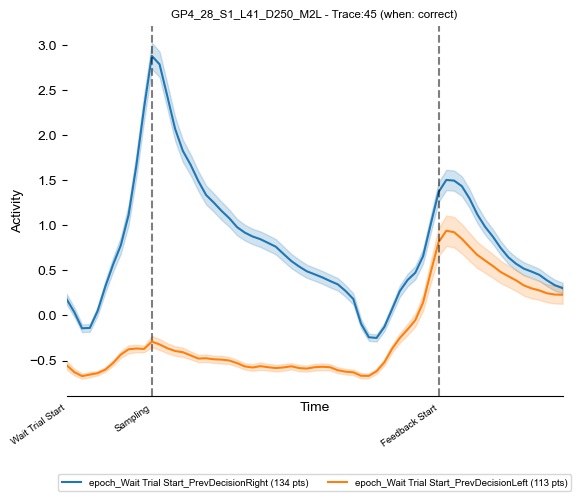

In [ ]:
from .twop.plottracesavg import plotNormalized as plotNormalizedT, Combinations, Plots
from functools import partial

plotNormalized = partial(plotNormalizedT, save_figs_outliers=False,
                         fig_save_prefix=fig_save_prefix,
                         normalization=normalization, split_level=SplitLevelBy.Session,
                         align_feedback_time=align_feedback_time,
                         limit_end_epoch=limit_end_epoch,
                         #normalize_by_session=normalize_by_session,
                         filter_outlier_trials=False)


combinations = [
  # Combinations.All,
  # Combinations.Evidence,
  # Combinations.EvidenceDirection,
#   Combinations.Direction,
#   Combinations.PrevDirCurDir,
#   Combinations.PrevDirCurDirAll,
  Combinations.PrevDirection,
  # Combinations.ChoiceCorrect,
  # Combinations.ChoiceCorrectCurDir,
#   Combinations.PrevChoiceCorrect,
#   Combinations.PrevChoiceCurDir,
  # Combinations.PrevChoicePrevDir,
  # Combinations.PrevChoicePrevDirCurDirLeft,
]
plots = [
        #  Plots.Heatmap,
         Plots.Traces,
         ]

def onlyTracesIds(set_name, traces_ids, group_info):
    # print("Group_info:", group_info, "- Set name:", set_name, "- traces:", traces_ids)
    target_trace_id = "45_GP4_28_S1_L41_D250_M2L"
    target_trace_id_int, short_name = target_trace_id.split("_", 1)
    name, date, sess_num = group_info["Name"], group_info["Date"], group_info["SessionNum"]
    incoming_short_name = sess_id_to_shortname[(name, date, sess_num)]
    if incoming_short_name != short_name:
        return set()
    target_trace_id_int = int(target_trace_id_int)
    return set([trace_id for trace_id in traces_ids
                # if "GP4_23_S1" in trace_id or "GP4_23_s8" in trace_id
                if target_trace_id_int == trace_id
                ])

plotNormalized(df_concat_norm=df_all_by_trial_normalized_concat, df_concat_without_feedback=None,
               combinations=combinations, cached_df_avgs=cached_df_avgs_traces,
               plots=plots,
               save_figs=False,
               plots_kargs={Plots.Heatmap:dict(plot_y_ids=False, dpi=300),
                            Plots.Traces:dict(sem_traces=True, save_ext="svg",)},
            #    only_traces_ids=[],
               onlyTraceIdsPlotProcessFn=onlyTracesIds,
            #    only_traces_ids=["GP4_23_s8_L50_D250_ALM126"],
            #    only_traces_ids=[#"GP4_85_s2_L100_D250_mm26",
            #                     #"GP4_85_s2_L100_D250_mm2_6",
            #                     # "6_GP4_85_s2_L100_D250_mm2",
            #                     # "7_GP4_85_S1_L70_D250_mm2",
            #                     # "45_GP4_28_S1_L41_D250_M2L",
            #                     "45_GP4_28_S1_L41_D250_M2L",
            #                     ],
)